In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle
import statsmodels.api as sm

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import lasso_path
from sklearn.linear_model import ridge_regression
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV

In [14]:
#Part 1
train_data = pd.read_csv("Hitters_train.csv")
test_data = pd.read_csv("Hitters_test.csv")
scaler = StandardScaler()
target_col = train_data.columns[-1]
feature_cols = [col for col in train_data.columns if col != target_col]
X_train = train_data[feature_cols]
y_train = train_data[target_col]
X_test = test_data[feature_cols]
y_test = test_data[target_col]
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
#Part 2
model = sm.OLS(y_train, sm.add_constant(X_train_scaled)).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     16   R-squared:                       0.549
Model:                            OLS   Adj. R-squared:                  0.511
Method:                 Least Squares   F-statistic:                     14.46
Date:                Sat, 21 Feb 2026   Prob (F-statistic):           4.01e-25
Time:                        00:51:17   Log-Likelihood:                -211.27
No. Observations:                 207   AIC:                             456.5
Df Residuals:                     190   BIC:                             513.2
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7.373e-17      0.049  -1.51e-15      1.000      -0.096       0.096
x1            -0.5246      0.230     -2.286      0.023      -0.977      -0.072
x2             0.4424      0.275      1.610      0.109      -0.100       0.984
x3             0.0154      0.143      0.108      0.914      -0.266       0.297
x4            -0.0134      0.185     -0.072      0.942      -0.379       0.352
x5             0.1753      0.172      1.022      0.308      -0.163       0.514
x6             0.2318      0.101      2.289      0.023       0.032       0.432
x7            -0.0154      0.153     -0.100      0.920      -0.318       0.287
x8            -0.9119      0.811     -1.125      0.262      -2.511       0.687
x9             1.2905      1.194      1.081      0.281      -1.065       3.645
x10            0.0225      0.342      0.066      0.948      -0.653       0.698
x11            0.7458      0.614      1.214      0.226      -0.466       1.957
x12           -0.3770      0.609     -0.619      0.537      -1.578       0.824
x13           -0.3141      0.233     -1.345      0.180      -0.775       0.146
x14            0.2132      0.054      3.951      0.000       0.107       0.320
x15            0.0639      0.086      0.744      0.458      -0.106       0.233
x16           -0.0378      0.076     -0.500      0.618      -0.187       0.111
==============================================================================
Omnibus:                       26.596   Durbin-Watson:                   2.062
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               46.495
Skew:                           0.682   Prob(JB):                     8.01e-11
Kurtosis:                       4.879   Cond. No.                         84.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Based on the OLS regression results provided, among the parameters, only x1, x6, and x14 are statistically significant at the alpha level of 0.05. The p-values for these three variables: x1 has a p-value of 0.023, x6 has a p-value of 0.023, and x14 has a p-value of 0.000, all of which are less than 0.05. Looking at their confidence intervals provides additional confirmation, as the interval for x1 ranges from -0.977 to -0.072, for x6 ranges from 0.032 to 0.432, and for x14 ranges from 0.107 to 0.320, none of which include zero.

Overall, the model is not bad when considering the global fit statistics. The F-statistic of 14.46 with a corresponding p-value of 4.01e-25 is highly significant. At the same time, the R-squared value of 0.549 represents an average result. At the same time, I might assume there are slight signs of overfitting. Only 3 parameters are statistically significant, suggesting that many of the predictors may be unnecessary.

Text(0, 0.5, 'Coefficients')

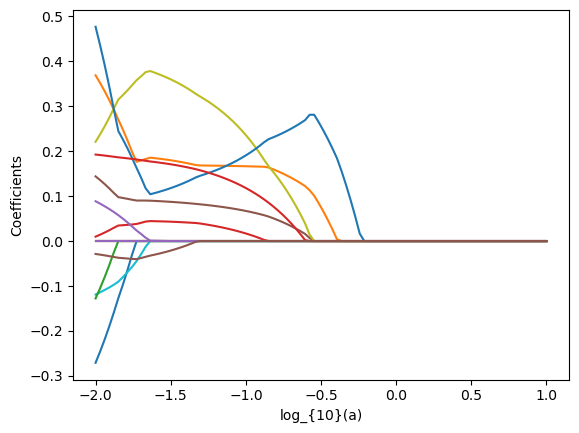

In [16]:
#Part 3

alphas_lasso = np.logspace(-2, 1, 100)
alphas_out, coefs_lasso, _ = lasso_path(X_train_scaled, y_train, alphas=alphas_lasso)
plt.plot(np.log10(alphas_out), coefs_lasso.T)

plt.xlabel('log_{10}(a)')
plt.ylabel('Coefficients')

Text(0, 0.5, 'Coefficients')

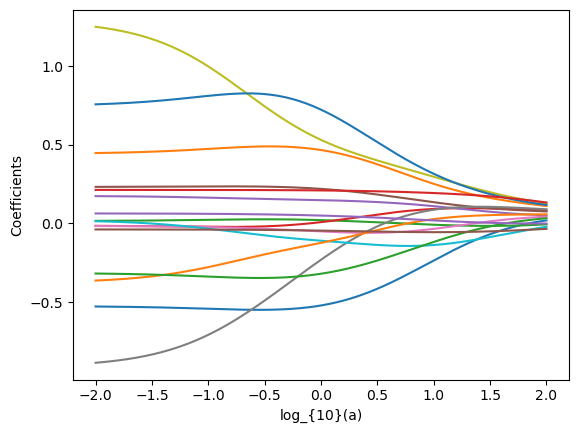

In [17]:
#Part 4

alphas_ridge = np.logspace(-2, 2, 200)
coefs_ridge = []
for i in alphas_ridge:
    coef = ridge_regression(X_train_scaled, y_train, alpha=i)
    coefs_ridge.append(coef)

plt.plot(np.log10(alphas_ridge), coefs_ridge)
plt.xlabel('log_{10}(a)')
plt.ylabel('Coefficients')

When comparing both plots, we can see that Ridge regression paths are much
smoother than Lasso regression paths (Similar pattern we observed in lecture). Lasso paths have sharp transitions and all of them harshly converges to 0 (too fast), while ridge paths asymptotically approach to zero, never really reaching zero. So we can observe the difference between different penatly structure (Since both of this paths differs by penatly structure).

In [18]:
#Part 5
linear = LinearRegression().fit(X_train_scaled, y_train)
ridge = RidgeCV(alphas=alphas_ridge).fit(X_train_scaled, y_train)
lasso = LassoCV(alphas=alphas_lasso).fit(X_train_scaled, y_train)

print(f"Linear Regression score: {linear.score(X_test_scaled, y_test)}")
print(f"Ridge score: {ridge.score(X_test_scaled, y_test)}")
print(f"Ridge alpha: {ridge.alpha_}")
print(f"Lasso score: {lasso.score(X_test_scaled, y_test)}")
print(f"Lasso alpha: {lasso.alpha_}")

Linear Regression score: 0.4049040960946786
Ridge score: 0.4416678499498974
Ridge alpha: 4.7137531341167245
Lasso score: 0.43483021913833475
Lasso alpha: 0.04328761281083057
